# Exercise: Explore the Embedding Space *(solution)*

This notebook demonstrates how to visualize high-dimensional embedding spaces to analyze and debug RAG pipelines. By projecting embeddings onto a 2D space using UMAP, you can identify clusters, highlight anomalies, and assess data quality.

- Dataset: first **2,000** passages from the [RAGQA tech corpus](../../data/ragqa/ragqa_arena_tech_corpus.jsonl)
- Stack: [ChromaDB](https://docs.trychroma.com/) persistent client + locally downloaded `all-MiniLM-L6-v2`

## What You'll Learn

- How to project embeddings using UMAP for visualization
- How to plot queries and their retrieval results in embedding space
- How to identify data coverage gaps
- How to cluster and label embedding regions with an LLM


## How each section works:

1. **I do** — we run one worked example together
2. **You do** — you investigate using only what was introduced so far

Pause before each *You do* cell and write down what you **expect** to see, then compare with the output.


## Setup

We use four libraries in this notebook — each solves one step of the embedding-space workflow:

- **[ChromaDB](https://docs.trychroma.com/)** — embeds passages and runs nearest-neighbor retrieval. Its `DefaultEmbeddingFunction` downloads **`all-MiniLM-L6-v2`** (~79 MB) on first use and runs locally (no API keys).
- **[umap-learn](https://umap-learn.readthedocs.io/)** — projects 384-dimensional embedding vectors down to 2D so we can scatter-plot them. Unlike PCA, UMAP tries to keep *neighbor relationships* from the original space (similar passages stay near each other on the map).
- **[pandas](https://pandas.pydata.org/)** — holds passage metadata and 2D coordinates in tables we can filter and join.
- **[seaborn](https://seaborn.pydata.org/)** — builds the scatter plots on top of matplotlib.

**Changing the embedding model:** this notebook uses Chroma's default local model. To swap models, replace `DefaultEmbeddingFunction()` with another [Chroma embedding function](https://docs.trychroma.com/docs/embeddings/embedding-functions) (for example `SentenceTransformerEmbeddingFunction(model_name="...")` from the [supported models list](https://docs.trychroma.com/docs/embeddings/embedding-functions#sentence-transformer)). You must use the *same* function for ingest and query, and re-ingest the collection after a model change.

Install dependencies from the repo root if needed:

```bash
uv add chromadb umap-learn
```


In [1]:
# Run from repo root if packages are missing:
# uv add chromadb umap-learn


## Load data and build the embedding map

### Load from `jsonl` file

We keep the **first 2,000 lines** of the RAGQA tech corpus, embed them with Chroma's default local model, and project the vectors to 2D with UMAP.


In [3]:
import json
from pathlib import Path

import pandas as pd  # https://pandas.pydata.org/

# Stop after this many lines so UMAP stays fast on a laptop (reference notebook loads a fixed cloud collection)
MAX_ROWS = 2_000

# Resolve paths relative to this notebook directory
HERE = Path(".").resolve()
CORPUS_PATH = HERE.parents[1] / "data" / "ragqa" / "ragqa_arena_tech_corpus.jsonl"

rows: list[dict] = []

# RAGQA stores one JSON object per line — each line is one passage we will embed
with CORPUS_PATH.open(encoding="utf-8") as corpus_file:
    for line_number, line in enumerate(corpus_file):
        if line_number >= MAX_ROWS:
            break
        record = json.loads(line)
        rows.append(
            {
                "doc_id": str(record["doc_id"]),  # Chroma primary key
                "author": record.get("author") or "unknown",  # metadata for later inspection
                "text": record["text"],  # passage body sent to the embedder
            }
        )

corpus_df = pd.DataFrame(rows)
# Short chunks sometimes land in odd regions on the map — length helps spot them
corpus_df["text_length"] = corpus_df["text"].str.len()

print(f"Loaded {len(corpus_df):,} passages")
# plot_df is built later from Chroma after ingest (mirrors reference notebook's df from collection.get)
corpus_df.head()


Loaded 2,000 passages


,doc_id,author,text,text_length
0,229377,Gilles 'SO- stop being evil',The primary command to manipulate deb packages...,2022
1,6,Adam Dempsey,You can use StartSound.PrefPane which basicall...,130
2,131078,unknown,http://abtevrythng.blogspot.com/2010/06/adding...,400
3,65554,user132360,In App purchases are not shared in Family shar...,287
4,34,Shane Stillwell,I would recommend installing QuickSilver. Its ...,279


### Insert records into ChromaDB collection


In [4]:
import chromadb  # https://docs.trychroma.com/
from chromadb.utils.embedding_functions import (  # https://docs.trychroma.com/docs/embeddings/embedding-functions
    DefaultEmbeddingFunction,
)

# Write vectors to disk so re-running skips re-embedding (reference uses Chroma Cloud with the same idea)
CHROMA_DIR = HERE / ".chroma_visualize_embeddings"
COLLECTION_NAME = "ragqa-tech-viz"
BATCH_SIZE = 100  # avoid one giant write when adding 2,000 passages

CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# Downloads all-MiniLM-L6-v2 on first call — must match query embedding in plot_query_overlay
embedding_function = DefaultEmbeddingFunction()
client = chromadb.PersistentClient(
    path=str(CHROMA_DIR),  # on-disk store under this notebook folder
)
collection = client.get_or_create_collection(
    name=COLLECTION_NAME,  # logical bucket for our RAGQA slice
    embedding_function=embedding_function,  # embeds documents on add() and query()
)

# Second run: collection already populated — skip ingest
if collection.count() == 0:
    print(f"Ingesting {len(corpus_df):,} passages into Chroma…")

    for start in range(0, len(corpus_df), BATCH_SIZE):
        batch = corpus_df.iloc[start : start + BATCH_SIZE]
        collection.add(
            ids=batch["doc_id"].tolist(),  # unique id per passage
            documents=batch["text"].tolist(),  # text Chroma embeds and stores
            metadatas=[
                {
                    "author": author,
                    "text_length": int(text_length),
                }
                for author, text_length in zip(
                    batch["author"],
                    batch["text_length"],
                    strict=True,
                )
            ],
        )
        print(f"  ingested {min(start + BATCH_SIZE, len(corpus_df)):,} / {len(corpus_df):,}")

print(f"Collection count: {collection.count():,}")


Collection count: 2,000


## Project the embeddings using UMAP

We will project our embeddings onto a 2-dimensional space using `umap`; it is similar to PCA in the sense that it is a **dimensionality reduction** technique, but `umap` tries to preserve the distances between points as much as possible from the original vector space, whereas PCA tries to find the dominant directions onto which the data is then projected.

Here, we fit a `umap` transformer to the **384-d vectors** Chroma stored for each RAGQA passage. We set the random seeds so query overlays land in the same spot every run.

_Note:_ You might see a warning about the random state being set. That is intentional so results stay consistent across runs.


/home/halgoz/work/Bootcamp/ai-pros/public/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


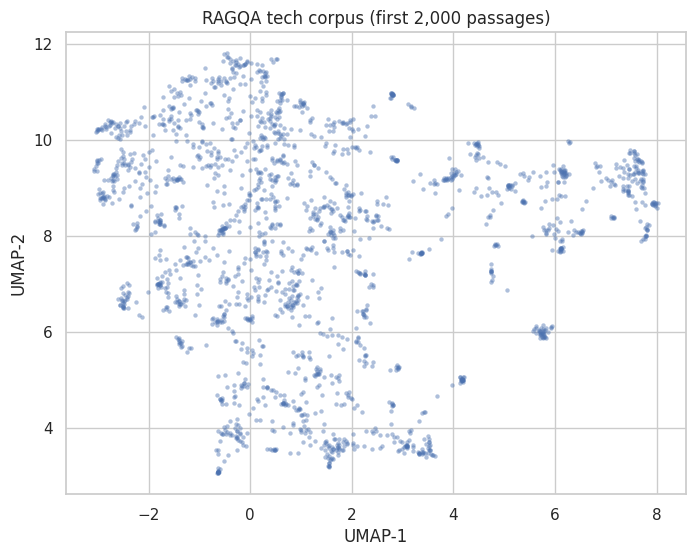

In [5]:
import matplotlib.pyplot as plt  # https://matplotlib.org/
import numpy as np  # https://numpy.org/
import seaborn as sns  # https://seaborn.pydata.org/
import umap  # https://umap-learn.readthedocs.io/

# Same seeds as reference visualizations.ipynb (random_state=0, transform_seed=0)
RANDOM_STATE = 0

sns.set_theme(style="whitegrid")

# Pull the same 384-d MiniLM vectors Chroma stored at ingest (reference: records = collection.get(...))
stored = collection.get(
    include=["documents", "metadatas", "embeddings"],
)

embeddings = np.array(stored["embeddings"])
plot_df = pd.DataFrame(
    {
        "doc_id": stored["ids"],
        "text": stored["documents"],
        "author": [meta["author"] for meta in stored["metadatas"]],
        "text_length": [meta["text_length"] for meta in stored["metadatas"]],
    }
)

# Fit once on the full corpus; later we call .transform() for query vectors (reference fits then projects in a loop)
umap_model = umap.UMAP(
    random_state=RANDOM_STATE,  # same 2D layout every notebook run
    transform_seed=RANDOM_STATE,  # query points land consistently when we call .transform()
)
projected = umap_model.fit_transform(embeddings)

# Reused by every overlay plot (reference keeps projected_dataset_embeddings)
plot_df["x"] = projected[:, 0]
plot_df["y"] = projected[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="x",  # first UMAP axis — nearby points were similar in 384-d space
    y="y",  # second UMAP axis
    s=10,  # small markers; 2,000 points overlap in dense regions
    alpha=0.45,  # transparency so dense blobs look darker
    linewidth=0,  # no marker outline
    ax=ax,
)
ax.set_title("RAGQA tech corpus (first 2,000 passages)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.show()


## Who can answer what in this notebook?

Use this map to connect stakeholder questions to the section where you can **see evidence**:

- **Clusters** tell you: what topics does our knowledge base actually cover?
- **Queries** tell you whether this query type retrievable with our current stack? (tight vs scattered hit groups)
  - Did chunking create semantic fragments in wrong regions? 


---

## 1. Plotting Queries

Let's visualize a query and its retrieval results in embedding space.

We will plot:

- the full corpus in gray
- the **query** as a red **`X`**
- the **retrieved passages** as empty **green circles**

**Predict:** for a specific Linux package question, will the query and its hits land in the same neighborhood?


In [6]:
def plot_query_overlay(
    query_text: str,
    n_results: int = 5,
) -> None:
    """Plot corpus background, query (red X), and retrieved hits (green circles)."""
    # Chroma embeds the query with the collection model and returns nearest corpus IDs (reference pre-queries, then plot_query)
    query_hits = collection.query(
        query_texts=[query_text],  # same MiniLM model as ingest
        n_results=n_results,  # top-k passages by vector distance
        include=["documents", "distances"],  # distances print how far each hit is from the query
    )

    # UMAP needs the query vector — not a refit — so it lands on the same map as the corpus
    query_vector = np.array(embedding_function([query_text])[0])
    query_xy = umap_model.transform(query_vector.reshape(1, -1))
    hit_ids = query_hits["ids"][0]
    retrieved_rows = plot_df[plot_df["doc_id"].isin(hit_ids)]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Layer 1: full corpus in gray (reference: gray scatter of all points)
    sns.scatterplot(
        data=plot_df,
        x="x",
        y="y",
        color="lightgray",
        s=10,
        alpha=0.35,
        linewidth=0,
        ax=ax,
    )

    # Layer 2: query location as red X (reference: red X marker)
    sns.scatterplot(
        x=query_xy[:, 0],
        y=query_xy[:, 1],
        color="crimson",
        s=160,
        marker="X",
        linewidth=0,
        label="query",
        ax=ax,
    )

    # Layer 3: retrieved passages as hollow green circles (reference: green edge-only scatter)
    sns.scatterplot(
        data=retrieved_rows,
        x="x",
        y="y",
        facecolors="none",
        edgecolors="seagreen",
        s=110,
        linewidth=1.4,
        label="retrieved",
        ax=ax,
    )
    ax.set_title(f"Query overlay: {query_text}")
    ax.legend()
    plt.show()

    print("Retrieved passages:")
    for rank, (doc, distance) in enumerate(
        zip(
            query_hits["documents"][0],
            query_hits["distances"][0],
            strict=True,
        ),
        start=1,
    ):
        preview = doc[:180] + ("…" if len(doc) > 180 else "")
        # Lower distance ≈ closer in embedding space
        print(f"{rank}. distance={distance:.4f} | {preview}\n")


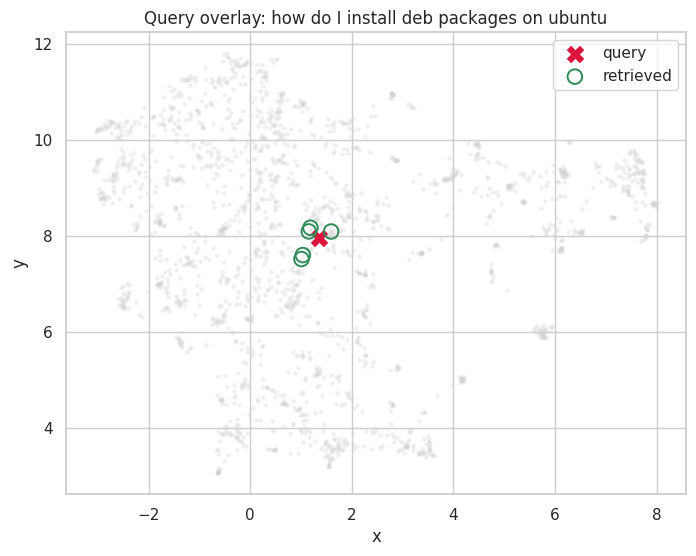

Retrieved passages:
1. distance=1.0424 | The primary command to manipulate deb packages is dpkg-deb. To unpack the package, create an empty directory and switch to it, then run dpkg-deb to extract its control information …

2. distance=1.1268 | There is a cool website where you can search for the packages and it will list the necessary command to install the stuff. BrewInstall is the website. Suppose you want to install w…

3. distance=1.1276 | Alternatively you can try, sudo installer -pkg ~/Downloads/packagename.pkg -target ~/Applications/ OR installer -pkg ~/Downloads/packagename.pkg -target ~/Applications/

4. distance=1.1668 | You can use fpm with the --after-install option to replace the postinst script, like this: fpm -e --after-install ../DEBIAN/postinst.new -s deb -t deb ../old.deb

5. distance=1.2414 | If you right click it, and click Show Package Contents youll get a few files in a Contents folder. (Note: if you do not see Show Package Contents you will need to open Terminal

In [7]:
# Specific Linux question — expect query + hits in one tight neighborhood (reference: account deletion)
SPECIFIC_QUERY = "how do I install deb packages on ubuntu"

plot_query_overlay(SPECIFIC_QUERY)


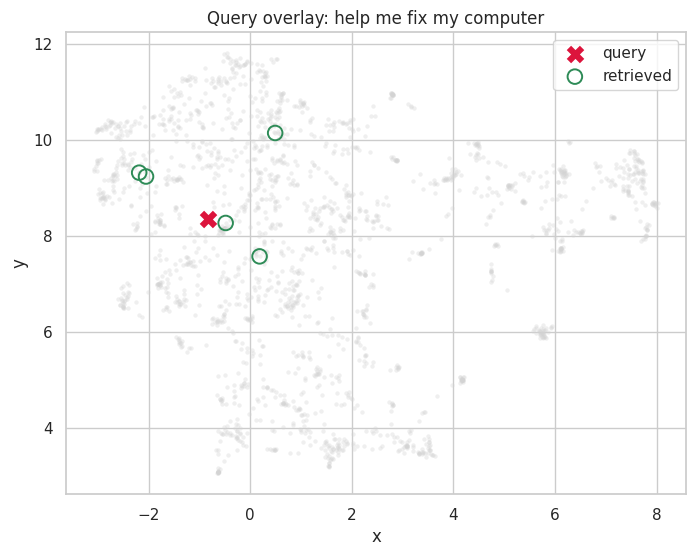

Retrieved passages:
1. distance=1.3470 | I doubt you can fix this without rooting the phone. But, if you are ready to root, you can try Autorun manager.

2. distance=1.3654 | Ctrl+R for you windows users out there.

3. distance=1.3833 | In a terminal, press Ctrl+G and then Enter

4. distance=1.4009 | Or you can do rm ./--help

5. distance=1.4391 | Holding down the ⌥ while booting to select the startup volume. Holding down C while booting to boot from a CD/DVD in the drive.



In [8]:
# Vague help request — expect scattered hits across the map (reference: "I need help with something")
VAGUE_QUERY = "help me fix my computer"

plot_query_overlay(VAGUE_QUERY)


### You do: compare two queries

**Predict** before you run the cells:

- Which query will have retrieved points **close together** on the map?
- Which query will look **scattered**?

Try one **specific** and one **vague** query of your own using `plot_query_overlay(...)`.

**Reflect (product owner):** when a vague query scatters, what should the product do instead of stuffing every hit into the LLM context?


=== Specific query ===


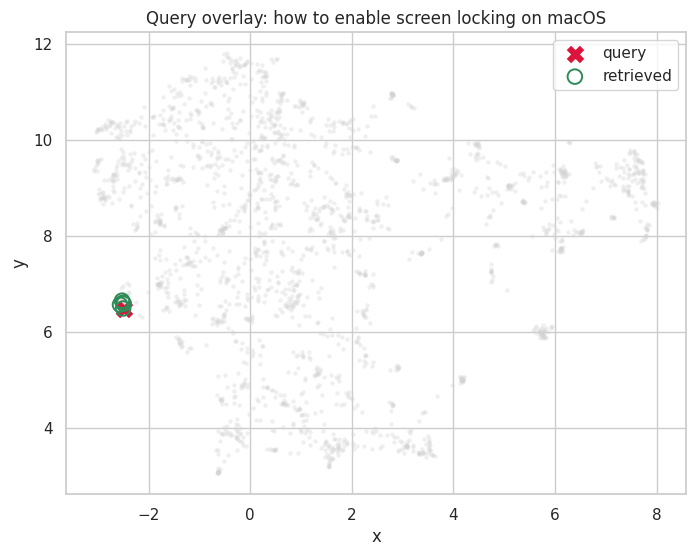

Retrieved passages:
1. distance=0.5553 | On macOS High Sierra, there is a standard key sequence and Apple menu item to lock your screen. Control-Command-Q or ^+⌘+Q For older OS, ⇧+⌃+⏏ puts the display (only the display, n…

2. distance=0.7119 | High Sierra and higher(?) As usual every system update changes something. There is now a Apple Menu item control+⌘+Q that locks the screen! Sierra and lower You can add the Lock Sc…

3. distance=0.7337 | There is a wonderful tool Karabiner that can help you with this (and many more): Properties->Misc&Uninstall -> private.xml <root> <!-- Place this file to ~/Library/Application Supp…

4. distance=0.7531 | First, you should enable requiring the password when the screen saver or display sleep begins. To do that go to Now, when you press the key combination control+shift+power (control…

5. distance=0.7904 | Quoting myself from https://github.com/tjluoma/lockscreen: Download and install FastScripts (which is free for up to 10 keyboard shortcuts) Dow

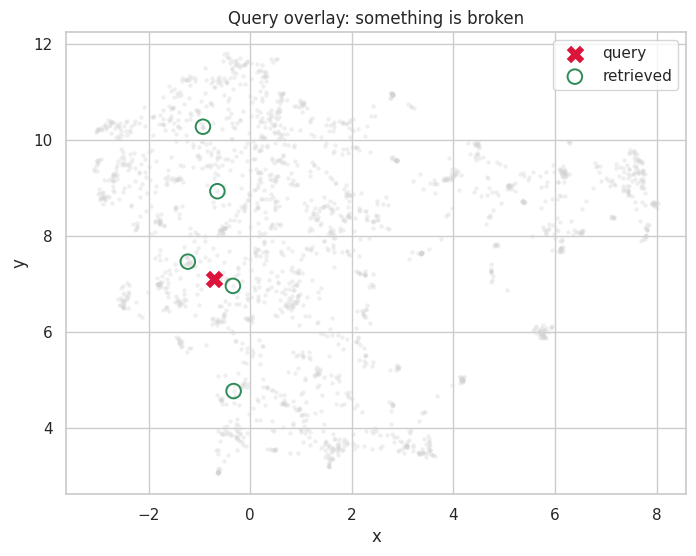

Retrieved passages:
1. distance=1.3943 | Another cause for the Broken Pipe message is that another machine is attempting use the same IP as your host. A simple way to test if someone else is using that IP: Turn off your h…

2. distance=1.4044 | Yes - all computer batteries from Apple (including the newer unibody models where the battery is not consumer replaceable) are easily swapped in a 10 to 35 minute procedure to open…

3. distance=1.4674 | I had kind of this issue. This was a program that I had launched with strace and interrupted with Ctrl+C. It ended up in a T (traced or stopped) state. I dont know how it happened …

4. distance=1.4984 | Try to relaunch the Finder. Here it works

5. distance=1.5122 | This can happen for a number of reasons and you might not know why. First, do the easy stuff, like you already did. Search with Spotlight, check for a new Home screen by swiping to…



In [9]:
# You do: predict which query clusters tightly vs scatters before running
MY_SPECIFIC_QUERY = "how to enable screen locking on macOS"
MY_VAGUE_QUERY = "something is broken"

print("=== Specific query ===")
plot_query_overlay(MY_SPECIFIC_QUERY)

print("=== Vague query ===")
plot_query_overlay(MY_VAGUE_QUERY)


---

## 2. Identifying Gaps

Visualizing the space is also helpful for identifying **coverage gaps** in our data.

For example, when we issue the query **Is your platform GDPR compliant**:

**Predict:** will the query land near existing passages, or in an empty region? Will the retrieved text actually mention compliance?


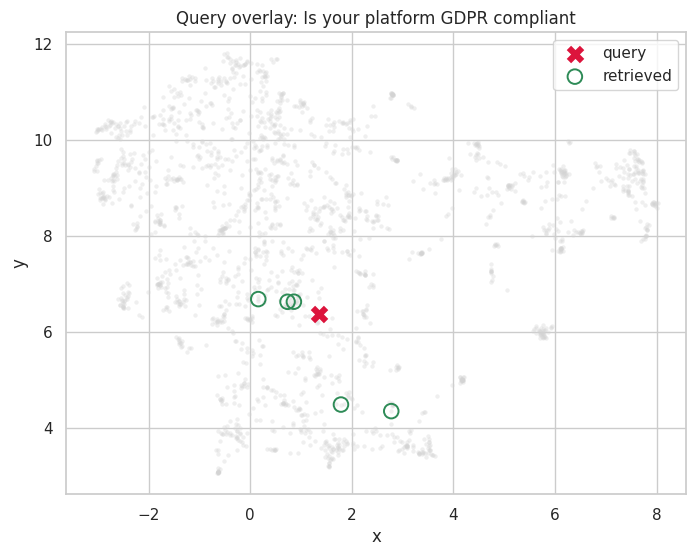

Retrieved passages:
1. distance=1.2821 | Well, given that its fully POSIX compliant I would say yes.

2. distance=1.3530 | I am amazed no one has mentioned the Google solution, Datally. No root required. More information on the Google blog: https://blog.google/technology/next-billion-users/meet-datally…

3. distance=1.3705 | Aurora Store is an open source fork of Yalp Store which provides a Material UI to the later. Aurora Store is an UnOfficial FOSS client to Googles Play Store, with an elegant design…

4. distance=1.3745 | Yalp Store allows the download of apps directly from Google Play Store. By default Yalp Store connects to Google services using a built-in account, so you do not have to own a Goog…

5. distance=1.3802 | Companies that are public (sell shares in stock exchanges) are regulated under Sarbanes-Oxley Act and are audited several times a year for compliance. Critical software application…



In [10]:
# Coverage-gap probe — reference visualizations.ipynb issues the same GDPR query
GDPR_QUERY = "Is your platform GDPR compliant"

plot_query_overlay(GDPR_QUERY)


When results are irrelevant and the query lands far from dense regions, that usually means the **corpus** lacks that topic — not that the LLM is "bad at GDPR."

**Reflect (data owner):** what content would you add before promising compliance answers?


### You do: probe another gap

Pick a topic you suspect is **missing** from this corpus slice (for example billing disputes, HIPAA, or a specific SaaS integration).

Run `plot_query_overlay(...)` and write one sentence on whether you see a coverage gap.


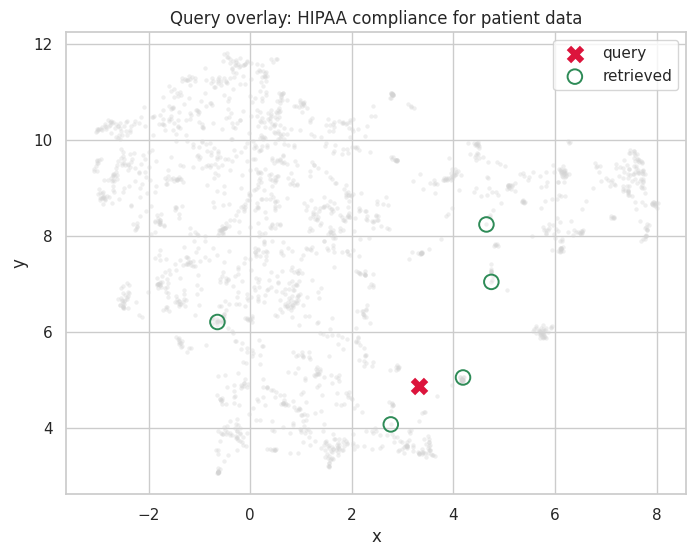

Retrieved passages:
1. distance=1.1737 | There is no one right answer to this. It depends on what you use the database for. In an enterprise application, you need the logic in the database through foreign keys, constraint…

2. distance=1.5059 | Coming at the question from a slightly different angle: Are you the CEO or CTO? No? Then do not give the auditors any passwords. Ever. Put an information package together and forwa…

3. distance=1.5279 | I usually use an identity column (auto-incremennting integer) when defining new tables for long-lived data (records I expect to insert once and keep around indefinitely even if the…

4. distance=1.5380 | Yes, private fields are absolutely necessary. Just this week I needed to write a custom dictionary implementation where I controlled what was put into the dictionary. If the dictio…

5. distance=1.5449 | The purpose of that feature is so that if there is an emergency you can dial an emergency number (911) without having to unlock the phone. Its 

In [11]:
# Second gap example — HIPAA likely lands in an empty region (corpus is general tech Q&A)
plot_query_overlay("HIPAA compliance for patient data")


---

## 3. Identifying Clusters

The visualization can help us identify clusters in our data. Looking at the baseline map, there appear to be roughly **12** topical regions.

Let's use `scikit-learn` to label them with KMeans on the 2D projection (a hypothesis tool, not ground truth).

**Predict:** will each cluster be topically pure, or will some mix unrelated tips?


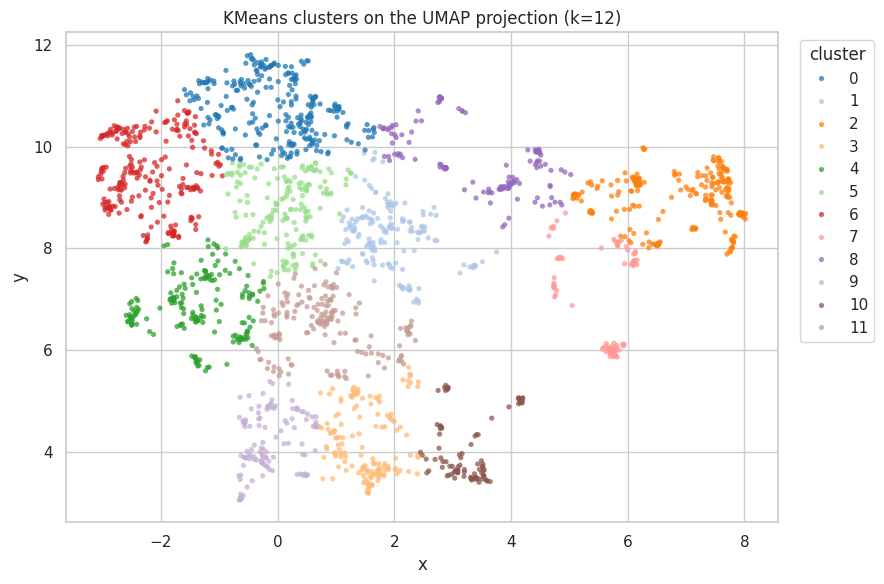

In [12]:
from sklearn.cluster import KMeans  # https://scikit-learn.org/

# ~12 visual blobs on the baseline map (reference: n_clusters = 12)
N_CLUSTERS = 12

# Cluster the 2D UMAP coords — a visualization hypothesis, not ground-truth topics in 384-d space
kmeans = KMeans(
    n_clusters=N_CLUSTERS,  # number of color groups to draw
    random_state=RANDOM_STATE,  # same partition every run
    n_init="auto",  # sklearn picks robust centroid restarts
)
plot_df["cluster"] = kmeans.fit_predict(projected)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="cluster",  # color from KMeans — algorithmic groups, not human labels yet
    palette="tab20",
    s=14,
    alpha=0.75,
    linewidth=0,
    ax=ax,
)
ax.set_title(f"KMeans clusters on the UMAP projection (k={N_CLUSTERS})")
ax.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()


In [13]:
# Sample a few passages per cluster for human labeling (reference: 5 docs per cluster → LLM category)
for cluster_id in range(N_CLUSTERS):
    cluster_rows = plot_df.loc[plot_df["cluster"] == cluster_id, "text"]
    sample_size = min(3, len(cluster_rows))
    sample_texts = cluster_rows.sample(
        n=sample_size,
        random_state=RANDOM_STATE,  # same exemplars every run
    ).tolist()

    print(f"\n=== Cluster {cluster_id} samples ===")
    for idx, text in enumerate(sample_texts, start=1):
        preview = text[:180] + ("…" if len(text) > 180 else "")
        print(f"{idx}. {preview}")



=== Cluster 0 samples ===
1. youre all overthinking this. cd .. mv fulldir/file.txt /tmp/ rm -rf fulldir mkdir fulldir mv /tmp/file.txt fulldir/ Done. EDIT Actually, easier: cd .. ln fulldir/file.txt ./ rm -rf…
2. One really easy way that I often use: cat args | xargs -P $NUM_PARALLEL command This will run the command, passing in each line of the args file, in parallel, running at most $NUM_…
3. Another way to convert GIF animation to video: ffmpeg -i your_gif.gif -c:v libvpx -crf 12 -b:v 500K output.mp4 -crf values can go from 4 to 63. Lower values mean better quality. -b…

=== Cluster 1 samples ===
1. Honestly, I agree that there are a lot of risks associated with using the root user as default. But let me just run through them and criticize some of the arguments a bit Defending…
2. Easier to do groups [username] If you want to list all local users and their local groups you can do cat /etc/passwd | awk -F: { print $1} | xargs -n1 groups If you get groups: com…
3. Shell functions I 

### You do: name two clusters from evidence

Pick **two** cluster IDs from the plot above.

For each one:

- Write a **human-readable label** (for example, "Linux package management" or "macOS shortcuts").
- Quote one passage that supports your label.
- Note one passage in the same cluster that **breaks** your label.

> Note: you can copy-paste into an LLM to do this automatically.


The following `categories` is from an LLM:


In [ ]:
# Precomputed cluster names — reference visualizations.ipynb calls OpenAI per cluster (cell 27).
# We ship fixed labels so this exercise runs without an API key.
categories = [
    {
        "cluster": 0,
        "category": "Command-Line Utilities & Automation Scripting",
        "core_theme": "Practical command-line snippets for file operations, parallel processing, and media conversion using tools like xargs and ffmpeg."
    },
    {
        "cluster": 1,
        "category": "Linux System Administration & Environment Setup",
        "core_theme": "OS-level management, shell custom functions, account permissions, and local user/group auditing."
    },
    {
        "cluster": 2,
        "category": "Software Engineering Culture & Workspace Dynamics",
        "core_theme": "Non-technical professional factors including code review communication, office perks, and developer job satisfaction."
    },
    {
        "cluster": 3,
        "category": "Network Security & Data Encryption",
        "core_theme": "Security risks over local networks/Wi-Fi, corporate HTTPS proxy interception, and application-layer transport encryption."
    },
    {
        "cluster": 4,
        "category": "Hardware Device Settings & OS Tweaks",
        "core_theme": "User adjustments for device behavior, including notification management, developer options, and legacy software compatibility layers."
    },
    {
        "cluster": 5,
        "category": "File Systems, Absolute Paths & Storage Mapping",
        "core_theme": "Storage paths, symbolic links in mobile environments (Android/SD cards), and tracking open files via system utilities like lsof."
    },
    {
        "cluster": 6,
        "category": "Application Preferences & UI Customization",
        "core_theme": "Modifying specific software behavior, clearing site data, mapping hotkeys, and configuring browser/terminal window layouts."
    },
    {
        "cluster": 7,
        "category": "Software Architecture, Lifecycle & CI/CD Strategy",
        "core_theme": "High-level development decisions regarding codebase refactoring ROI, continuous integration setups, and automated testing benefits."
    },
    {
        "cluster": 8,
        "category": "Code Design, Implementation Style & OOP Syntax",
        "core_theme": "Micro-level programming practices including code formatting, locality of reference, conditional formatting, and encapsulation via interfaces."
    },
    {
        "cluster": 9,
        "category": "Network Protocols & System Configuration",
        "core_theme": "Routing protocols (BGP path vectors), network bandwidth allocation, and local OS sharing settings."
    },
    {
        "cluster": 10,
        "category": "Data Modeling, Semantics & Information Security",
        "core_theme": "Conceptual definitions, database design choices (auto-incrementing keys), and human vulnerabilities in cryptography/PIN entropy."
    },
    {
        "cluster": 11,
        "category": "Open-Source Applications & Privacy Management",
        "core_theme": "Community-driven software data (OSM), mobile OS permission control, and credential management storage hooks."
    }
]


### You do: label the cluster map

You named a few clusters by hand. An LLM can propose labels for all **12** clusters at once — but the map is still hard to read without text on it.

**Predict:** will every label land near a visually coherent region, or will some sit between two color blobs?

Place each cluster's **category name** at its KMeans **centroid** on the scatter plot (clusters **0–11**).


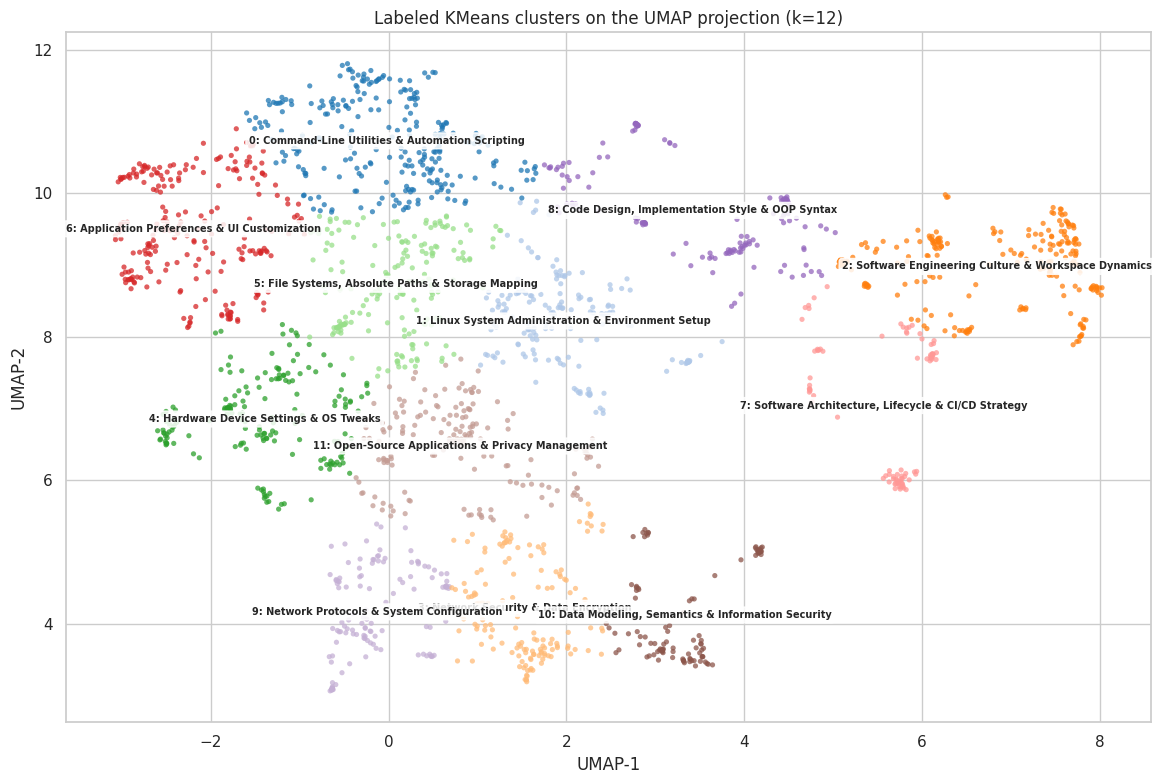

In [15]:
# Map cluster id → category string for annotation text
cluster_labels = {
    item["cluster"]: item["category"]
    for item in categories
}
# KMeans centroids in 2D — where we place each label (reference: centroid + cluster_names)
centroids = kmeans.cluster_centers_

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="cluster",
    palette="tab20",
    s=14,
    alpha=0.75,
    linewidth=0,
    legend=False,  # text labels at centroids replace a color legend
    ax=ax,
)

for cluster_id in range(N_CLUSTERS):
    centroid_x, centroid_y = centroids[cluster_id]
    ax.annotate(
        text=f"{cluster_id}: {cluster_labels[cluster_id]}",
        xy=(centroid_x, centroid_y),  # KMeans center of this color group
        fontsize=7,  # small font — 12 labels on one map
        fontweight="bold",
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

ax.set_title(f"Labeled KMeans clusters on the UMAP projection (k={N_CLUSTERS})")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.show()


---

## Wrap-up

You turned embedding space from a black box into something you can inspect:

- **Plotting queries** shows whether retrieval is tight or scattered
- **Identifying gaps** shows when the corpus — not the LLM — is the bottleneck
- **Identifying clusters** sketches what topics you actually have

Before shipping a RAG feature, pick one stakeholder question from the table at the top and answer it with a plot from this notebook.
